# CIFAR 10 Classification
## 1.2 Improving upon our existing baseline cnn archeticture

In [154]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import shutil

In [155]:
import numpy as np
import random
import os

seed = 42
# Setting Python and NumPy seeds
random.seed(seed)
np.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
    
# Setting PyTorch seeds (CPU and all GPUs)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
    
# Ensure deterministic behavior in cuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [156]:
# checking if CUDA is available and set the device accordingly,
# if a GPU is available it will use it for computations, otherwise it will fall back to using the CPU.
# in this case I am using RTX 3060 GPU which has CUDA support
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:
print(device)
 


cuda:0


In [ ]:
# If you ever wanted to retrain the models set the desired network flag to true
TRAIN_NETWORK_1 = False
TRAIN_NETWORK_2 = False
TRAIN_NETWORK_3 = False

# if set to true it will save accuracy, training time & loss over epochs
SAVE_TABLES = False
# If set to true it will delete all the saved csvs and models,
# THIS WILL CAUSE ERRORS IF YOU WANT TO RUN THE WHOLE NOTEBOOK AND DON'T WANT TO RETRAIN 
# THE 3 MODELS ONCE AGAIN SET ALL TRAIN_NETWORK FLAGS TO TRUE TO PERVENT THAT
DELETE_ALL = False

# if DELETE_ALL is set to True, the code will check if the '../tables'
# and '../models' directory exists and if it does,
# it will iterate through all the files in that directory and delete them.
# If any file cannot be deleted, it will print an error message with the reason for the failure
# I used AI to make this deletion part so I don't know the details of how it works but
# I assume it uses the os and shutil modules to perform file operations
if DELETE_ALL:
    if os.path.exists('../tables'):
        for filename in os.listdir('../tables'):
            file_path = os.path.join('../tables', filename)
            try:
                if os.path.isfile(file_path) or os.path.islink(file_path):
                    os.unlink(file_path)
                elif os.path.isdir(file_path):
                    shutil.rmtree(file_path)
            except Exception as e:
                print(f'Failed to delete {file_path}. Reason: {e}')
        
    if os.path.exists('../models'):
        for filename in os.listdir('../models'):
            file_path = os.path.join('../models', filename)
            try:
                if os.path.isfile(file_path) or os.path.islink(file_path):
                    os.unlink(file_path)
                elif os.path.isdir(file_path):
                    shutil.rmtree(file_path)
            except Exception as e:
                print(f'Failed to delete {file_path}. Reason: {e}')

Failed to delete ./tables\accuracy.csv. Reason: [WinError 32] The process cannot access the file because it is being used by another process: './tables\\accuracy.csv'


In [158]:
# creating two empty pandas DataFrames with specified columns
# to store training times and accuracies for different models, for later analysis and comparisons
training_time_table = pd.DataFrame(columns=['Model', 'Training Time (seconds)'])
test_accuracy = pd.DataFrame(columns=['Model', 'Accuracy (%)'])
loss_table = pd.DataFrame(columns=['Model', 'Epoch', 'Loss'])


## Preprocessing

In [ ]:
# same cell as previous notebook
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]
)

# increased the batch size to 32 for faster gpu training
batch_size = 32

trainset = torchvision.datasets.CIFAR10(root='../data', train=True,
                                        download=False, transform=transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

testset = torchvision.datasets.CIFAR10(root='../data', train=False,
                                        download=False, transform=transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## First nueral network with increased number of filters & neurons 
### NET 1

In [160]:
# same neural network architecture as previous notebook but with increased filters &
# neurons in the fully connected layers to see if it can achieve better performance

class Net1 (nn.Module):
    def __init__(self):
        super(Net1, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 5)
        
        self.pool= nn.MaxPool2d(2,2)
        
        self.conv2 = nn.Conv2d(16, 32, 5)
        
        self.fc1 = nn.Linear(32 * 5 * 5, 144)

        self.fc2 = nn.Linear(144, 98)

        self.fc3 = nn.Linear(98, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))

        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))

        x = F.relu(self.fc2(x))

        x = self.fc3(x)
        return x
    
net1 = Net1()

net1.to(device)

Net1(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=800, out_features=144, bias=True)
  (fc2): Linear(in_features=144, out_features=98, bias=True)
  (fc3): Linear(in_features=98, out_features=10, bias=True)
)

In [161]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
if TRAIN_NETWORK_1:
    optimizer1 = optim.SGD(net1.parameters(), lr=0.001, momentum=0.9)

In [162]:
if TRAIN_NETWORK_1:
    start = time.perf_counter()
    for epoch in range(10):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer1.zero_grad()
            outputs = net1(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer1.step()
            
            running_loss += loss.item()
        
        print(f'[Epoch {epoch + 1}] loss: {running_loss / len(trainloader):.3f}')
        if SAVE_TABLES:
            loss_table.loc[len(loss_table)] = {'Model': 'Baseline CNN + Increased', 'Epoch': epoch + 1, 'Loss': running_loss / len(trainloader)}
        

    end = time.perf_counter()
    time_gpu_increased = end - start
    print(f'Training time on GPU with increased filters, neurons and batchsize: {time_gpu_increased:.2f} seconds')

[Epoch 1] loss: 2.127
[Epoch 2] loss: 1.678
[Epoch 3] loss: 1.470
[Epoch 4] loss: 1.341
[Epoch 5] loss: 1.237
[Epoch 6] loss: 1.147
[Epoch 7] loss: 1.072
[Epoch 8] loss: 1.007
[Epoch 9] loss: 0.952
[Epoch 10] loss: 0.903
Training time on GPU with increased filters, neurons and batchsize: 138.24 seconds


In [ ]:
if not TRAIN_NETWORK_1:
    PATH = '../models/cifar_net_gpu_increased.pth'
    net1.load_state_dict(torch.load(PATH, map_location=device))

In [164]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = net1(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy_gpu_increased = 100 * correct / total
print(f'Accuracy of the network on the 10000 test images: {accuracy_gpu_increased:.2f}%')

Accuracy of the network on the 10000 test images: 66.56%


In [165]:
if TRAIN_NETWORK_1:
    training_time_table.loc[len(training_time_table)] = {'Model': 'Baseline CNN + Increased', 'Training Time (seconds)': round(time_gpu_increased, 2)}
    test_accuracy.loc[len(test_accuracy)] = {'Model': 'Baseline CNN + Increased', 'Accuracy (%)': round(accuracy_gpu_increased, 2)}

In [ ]:
if TRAIN_NETWORK_1:
    PATH = '../models/cifar_net_gpu_increased.pth'
    torch.save(net1.state_dict(), PATH)

## Second neural network similar to NET 1 but with batch normalization layers and same size padding
### NET 2

In [167]:
class Net2 (nn.Module):
    def __init__(self):
        super(Net2, self).__init__()
        # same first convolutional layer as previous network however I removed bias 
        # because of batch normalization layer will have offset trainable parameter anyway
        # kept padding the same to see if keeping the edge information of the input images 
        # will help the network to learn better features
        # the first convolutional layer will keep the same size of the original input images
        # which is 32x32 instead of reducing it to 28x28 as in the previous network
        self.conv1 = nn.Conv2d(3, 16 ,5 , padding="same", bias = False)
        # batch normalization layer after the first convolutional layer to normalize the activations
        # and improve training stability it takes the number of output channels
        # from the first convolutional layer which is 16 as an argument
        # z = (x - mean) / sqrt(var + eps) * gamma + beta(offset)
        # this will not change the size of the output from the first convolutional layer
        # which is 32x32
        self.bn1 = nn.BatchNorm2d(16)
        # max pooling as previous network to reduce the spatial dimensions of the feature maps by half
        # now the output size will be 16x16 instead of 14x14 as in the previous network
        self.pool= nn.MaxPool2d(2,2)
        # second convolutional layer similar to the previous network
        # but without bias also due to batch normalization layer after it
        self.conv2 = nn.Conv2d(16, 32, 5, bias = False)
        # batch normalization layer also taking the number of output channels
        # from the second convolutional layer which is 32
        self.bn2 = nn.BatchNorm2d(32)
        # same fully connected layers but with input size in first layer changed from 32*5*5 to 32*6*6 
        # due to the change in the output size of the second convolutional layer
        self.fc1 = nn.Linear(32 * 6 * 6, 144)
        self.fc2 = nn.Linear(144, 98)
        self.fc3 = nn.Linear(98, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
        
net2 = Net2()
net2.to(device)

Net2(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=same, bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=1152, out_features=144, bias=True)
  (fc2): Linear(in_features=144, out_features=98, bias=True)
  (fc3): Linear(in_features=98, out_features=10, bias=True)
)

In [168]:
# same optimizer as previous network
optimizer2 = optim.SGD(net2.parameters(), lr=0.001, momentum=0.9)

In [169]:
# same training loop as previous network but using net2 and optimizer2 to train 
# the new architecture with batch normalization and padding
if TRAIN_NETWORK_2:
    start = time.perf_counter()
    for epoch in range(10):
        running_loss = 0.0
        for data in trainloader:
            inputs, labels = data
            
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer2.zero_grad()
            
            outputs = net2(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer2.step()
            
            running_loss += loss.item()
        print(f'[Epoch {epoch + 1}] loss: {running_loss / len(trainloader):.3f}')
        if SAVE_TABLES:
            loss_table.loc[len(loss_table)] = {'Model': 'Baseline CNN + Increased + Padding + Batch Normalization', 'Epoch': epoch + 1, 'Loss': running_loss / len(trainloader)}
        
    end = time.perf_counter()
    time_gpu_increased_pd_bn = end - start
    print(f'Training time on GPU with increased filters, neurons, batchsize and batch normalization: {time_gpu_increased_pd_bn:.2f} seconds')

[Epoch 1] loss: 1.606
[Epoch 2] loss: 1.193
[Epoch 3] loss: 1.031
[Epoch 4] loss: 0.938
[Epoch 5] loss: 0.862
[Epoch 6] loss: 0.805
[Epoch 7] loss: 0.749
[Epoch 8] loss: 0.705
[Epoch 9] loss: 0.665
[Epoch 10] loss: 0.625
Training time on GPU with increased filters, neurons, batchsize and batch normalization: 139.96 seconds


In [ ]:
# using the saved trained model if TRAIN_NETWORK_2 is False
if not TRAIN_NETWORK_2:
     PATH = '../models/cifar_net_gpu_increased_pd_bn.pth'
     net2.load_state_dict(torch.load(PATH, map_location=device))

In [171]:
# Evaluate net2 on the test set
total = 0
correct = 0

with torch.no_grad():
    net2.eval()
    for data in testloader:
        images, labels = data

        images = images.to(device)
        labels = labels.to(device)

        outputs = net2(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy_gpu_increased_pd_bn = 100 * correct / total
print(f'Accuracy of the network on the 10000 test images: {accuracy_gpu_increased_pd_bn:.2f}%')


Accuracy of the network on the 10000 test images: 73.34%


In [ ]:
# if TRAING_NETWORK_2 is True, we save the trained model
if TRAIN_NETWORK_2:
     PATH = '../models/cifar_net_gpu_increased_pd_bn.pth'
     torch.save(net2.state_dict(), PATH)

In [173]:
# adding the training time and accuracy of the new architecture with batch normalization and padding
# to the respective tables for later analysis and comparisons
if TRAIN_NETWORK_2:
    training_time_table.loc[len(training_time_table)] = {'Model': 'Baseline CNN + Increased + Padding + Batch Normalization', 'Training Time (seconds)': round(time_gpu_increased_pd_bn, 2)}
    test_accuracy.loc[len(test_accuracy)] = {'Model': 'Baseline CNN + Increased + Padding + Batch Normalization', 'Accuracy (%)': round(accuracy_gpu_increased_pd_bn, 2)}


## Third neural network similar to NET 2 but with a dropout layer after the first FC layer

In [174]:
class Net3 (nn.Module):
    def __init__(self):
        super(Net3, self).__init__()
        # same first convolutional layer as previous network
        self.conv1 = nn.Conv2d(3, 16 ,5 , padding="same", bias = False)

        # batch normalization layer after the first convolutional layer to normalize the activations
        self.bn1 = nn.BatchNorm2d(16)
        
        # max pooling layer
        self.pool= nn.MaxPool2d(2,2)
        
        # second convolutional layer similar to the previous network
        self.conv2 = nn.Conv2d(16, 32, 5, bias = False)
        
        # batch normalization layer
        self.bn2 = nn.BatchNorm2d(32)
        # same fully connected layers but with input size in first layer changed from 32*5*5 to 32*6*6 
        # due to the change in the output size of the second convolutional layer
        self.fc1 = nn.Linear(32 * 6 * 6, 144)
        # adding a dropout layer with a dropout probability of 0.5
        # after the first fully connected layer to see if it will improve the performance 
        # of the network by reducing overfitting
        self.dropout = nn.Dropout(0.25)
        self.fc2 = nn.Linear(144, 98)
        self.fc3 = nn.Linear(98, 10)
        
    def forward(self, x):
        # same forward pass as previous network but with dropout layer added
        # after the first fully connected layer
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net3 = Net3()
net3.to(device)

Net3(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=same, bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), bias=False)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=1152, out_features=144, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=144, out_features=98, bias=True)
  (fc3): Linear(in_features=98, out_features=10, bias=True)
)

In [175]:
optimizer3 = optim.SGD(net3.parameters(), lr=0.001, momentum=0.9)

In [176]:
# same training loop as previous network but using net3 and optimizer3 to train 
# the new architecture with batch normalization and padding and dropout
net3.train()
if TRAIN_NETWORK_3:
    start = time.perf_counter()
    for epoch in range(10):
        running_loss = 0.0
        for data in trainloader:
            inputs, labels = data
            
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer3.zero_grad()
            
            outputs = net3(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer3.step()
            
            running_loss += loss.item()
        print(f'[Epoch {epoch + 1}] loss: {running_loss / len(trainloader):.3f}')
        if SAVE_TABLES:
            loss_table.loc[len(loss_table)] = {'Model': 'Baseline CNN + Increased + Padding + Batch Normalization + Dropout', 'Epoch': epoch + 1, 'Loss': running_loss / len(trainloader)}
        
    end = time.perf_counter()
    time_gpu_increased_pd_bn_do = end - start
    print(f'Training time on GPU with increased filters, neurons, batchsize and batch normalization + Dropout: {time_gpu_increased_pd_bn_do:.2f} seconds')

[Epoch 1] loss: 1.656
[Epoch 2] loss: 1.260
[Epoch 3] loss: 1.096
[Epoch 4] loss: 0.992
[Epoch 5] loss: 0.928
[Epoch 6] loss: 0.876
[Epoch 7] loss: 0.831
[Epoch 8] loss: 0.784
[Epoch 9] loss: 0.751
[Epoch 10] loss: 0.721
Training time on GPU with increased filters, neurons, batchsize and batch normalization + Dropout: 139.62 seconds


In [ ]:
# using the saved trained model if TRAIN_NETWORK_3 is False
if not TRAIN_NETWORK_3:
     PATH = '../models/cifar_net_gpu_increased_pd_bn_do.pth'
     net3.load_state_dict(torch.load(PATH, map_location=device))

In [178]:
# same evaluation loop as previous network but using net3 
# to evaluate the new architecture with batch normalization, padding, dropout and adam optimizer
total = 0
correct = 0
with torch.no_grad():
    net3.eval()
    for data in testloader:
        images, labels = data
        
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = net3(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy_gpu_increased_pd_bn_do = 100 * correct / total
print(f'Accuracy of the network on the 10000 test images: {accuracy_gpu_increased_pd_bn_do:.2f}%')

Accuracy of the network on the 10000 test images: 73.12%


In [ ]:
# if TRAING_NETWORK_3 is True, we save the trained model
if TRAIN_NETWORK_3:
     PATH = '../models/cifar_net_gpu_increased_pd_bn_do.pth'
     torch.save(net3.state_dict(), PATH)

In [180]:
if TRAIN_NETWORK_3:
    training_time_table.loc[len(training_time_table)] = {'Model': 'Baseline CNN + Increased + Padding + Batch Normalization  + Dropout', 'Training Time (seconds)': round(time_gpu_increased_pd_bn_do, 2)}
    test_accuracy.loc[len(test_accuracy)] = {'Model': 'Baseline CNN + Increased + Padding + Batch Normalization  + Dropout', 'Accuracy (%)': round(accuracy_gpu_increased_pd_bn_do, 2)}

In [ ]:
if not SAVE_TABLES:
    training_time_table = pd.read_csv("../tables/training_times.csv")
    loss_table = pd.read_csv("../tables/loss.csv")
    test_accuracy = pd.read_csv("../tables/accuracy.csv").drop(columns=["Train Accuracy"])

In [182]:
# Testing each net on the training set to check training accuracy
nets = [net1, net2, net3]
nets_name = list(test_accuracy["Model"])
train_accuracy = pd.DataFrame(columns=["Model", "Accuracy (%)"])

for i, net in enumerate(nets):
    total = 0
    correct = 0

    with torch.no_grad():
        net.eval()  # use eval mode so BatchNorm/Dropout behave consistently
        for data in trainloader:   # <-- use TRAIN loader, not testloader
            images, labels = data

            images = images.to(device)
            labels = labels.to(device)

            outputs = net(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    train_accuracy.loc[len(train_accuracy)] = {
        'Model': nets_name[i],
        'Accuracy (%)': round(accuracy, 2)
    }

train_accuracy


,Model,Accuracy (%)
0,Baseline CNN + Increased,71.02
1,Baseline CNN + Increased + Padding + Batch Nor...,80.85
2,Baseline CNN + Increased + Padding + Batch Nor...,80.04


C:\Users\Ahmed\AppData\Local\Temp\ipykernel_25280\2030960771.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


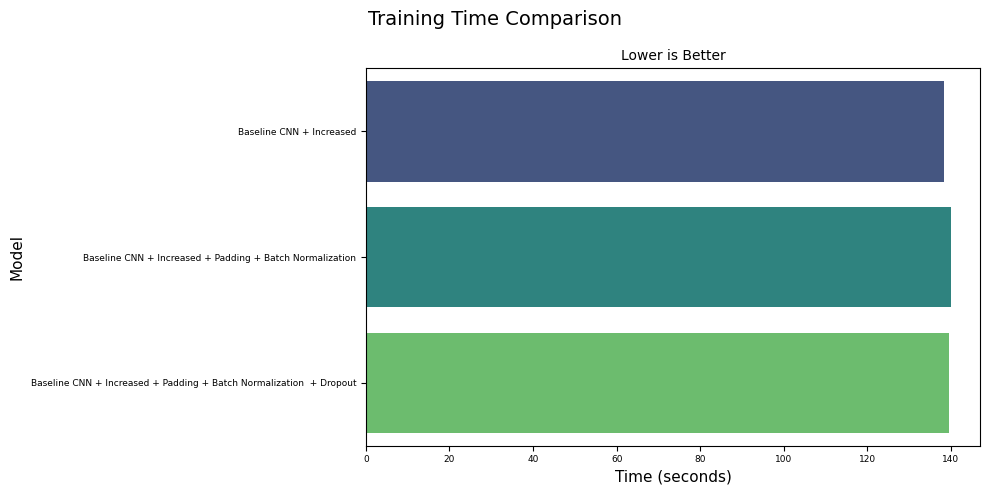

In [183]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))  # make plot wider/taller

sns.barplot(
    x=training_time_table["Training Time (seconds)"],
    y=training_time_table["Model"],
    palette="viridis"
)

plt.suptitle("Training Time Comparison", fontsize=14)
plt.title("Lower is Better", fontsize=10)
plt.xlabel("Time (seconds)", fontsize=11)
plt.ylabel("Model", fontsize=11)

plt.yticks(fontsize=6.5)   # smaller model names
plt.xticks(fontsize=6.5)

plt.tight_layout()       # adjusts spacing automatically
plt.show()

### It's clear that the model that had dropout had the highest training time this is because each forward pass the model has to scale the survivors by 1/1-p also it could be due to the model not learning efficiently, it may spend more time doing useless updates even though each epoch has the same number of batches


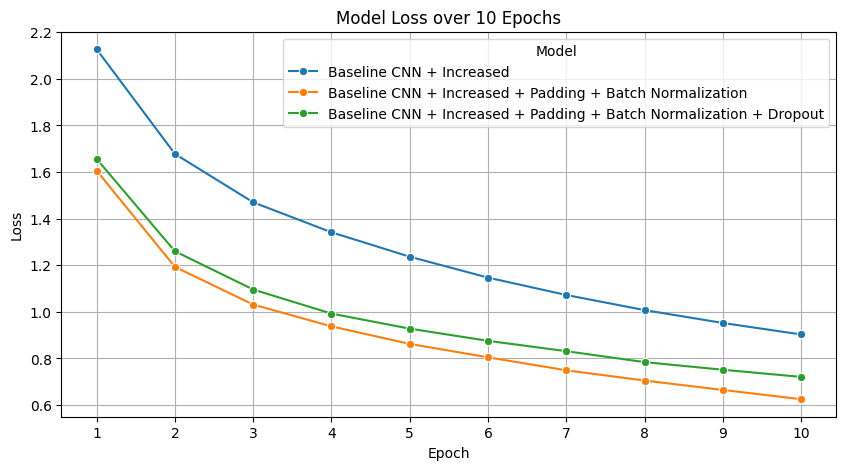

In [184]:
# loss line plot 
# comparing accuracies 
plt.figure(figsize=(10,5))
sns.lineplot(data=loss_table, x="Epoch", y="Loss", hue="Model", marker="o")

plt.title("Model Loss over 10 Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(range(1, 11))
plt.grid(True)
plt.legend(title="Model")
plt.show()

### - The baseline model with **increased neurons and filters** had the highest loss due to it having less spatial information about the images and not using per batch statistics

### - Same Model with **Padding + batch normalization** had the lowest loss which indicates that the model required more spatial information about the images and more accurate per batch statistics to perform better

### - Surprisingly **dropout** made the model perform worse on training data and yielded higher loss, this probably indicates that dropout made the model reguralize too hard and as a result performed worse

In [185]:
train_df = train_accuracy.rename(columns={"Accuracy (%)": "Train Accuracy"})
test_df = test_accuracy.rename(columns={"Accuracy (%)": "Test Accuracy"})

accuracy_table = pd.merge(train_df, test_df, on="Model")


df_long = accuracy_table.melt(
    id_vars="Model",
    value_vars=["Train Accuracy", "Test Accuracy"],
    var_name="Dataset",
    value_name="Accuracy (%)"
)

In [187]:
# saving the tables to csv files if SAVE_TABLES is True,
if SAVE_TABLES:
    training_time_table.to_csv("tables/training_times.csv", index=False)
    accuracy_table.to_csv("tables/accuracy.csv", index=False)
    loss_table.to_csv("tables/loss.csv", index=False)

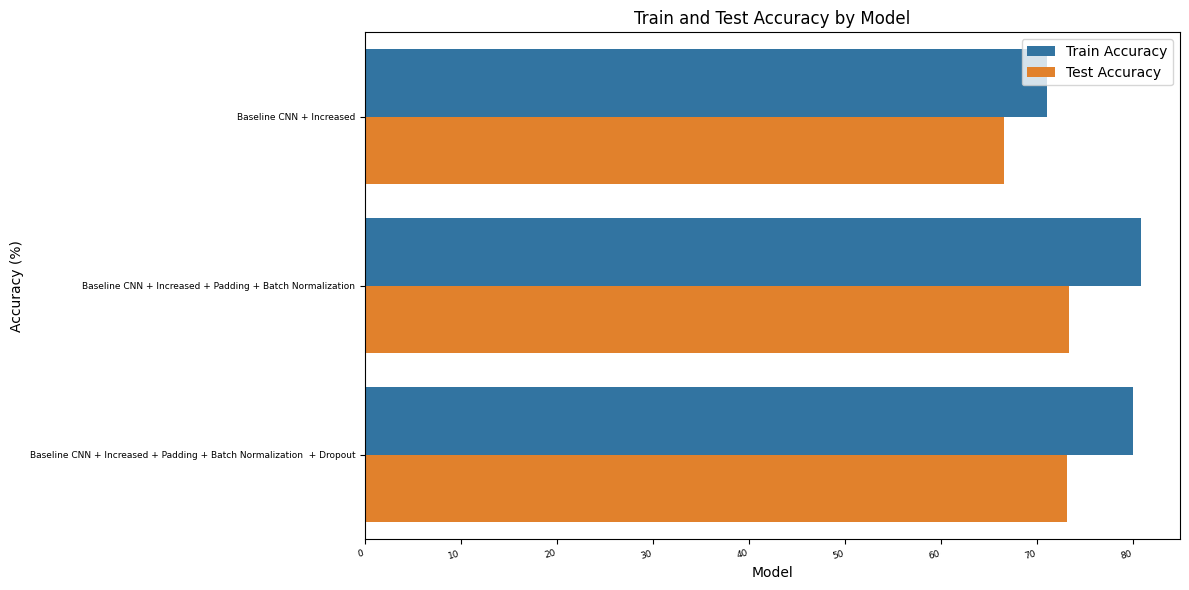

In [188]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_long, x="Accuracy (%)", y="Model", hue="Dataset")

plt.title("Train and Test Accuracy by Model")
plt.xlabel("Model")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15, ha="right")
plt.legend(title="")

plt.yticks(fontsize=6.5)
plt.xticks(fontsize=6.5)
plt.tight_layout()
plt.show()

### As Expected the network with padding and batch normalization only managed to get the highest test accuracy also the highest train accuracy, in all the models it seems that the train and test accuracy gap is slightly large which indicates that the model is overfitting

# In Conclusion
## I think I am reaching the limit with this baseline model, yes there's some tweaks I can do like changing the optimizer to use Adam, make the second convolution layer have the same padding or increasing the number of epochs, these tweaks might improve performance slightly but I don't expect a massive improvement at all without changing the core architechure itself or increasing the dataset size, in The next notebook I will explore data augmentation and change the architecture entirely I have to read about how models like resnet or imagenet work, so I can make a new and improved model